# AIVoiceMaker — Demo Notebook

Este notebook recorre todo el proyecto **AIVoiceMaker** de extremo a extremo:

1. Inspecciona el dataset preprocesado (chunks de audio + transcripciones automáticas).
2. Carga el modelo XTTS-v2 fine-tuneado.
3. Genera audio sobre prompts nuevos (no vistos durante el entrenamiento).
4. Calcula métricas objetivas: similitud de hablante (cosine sobre embeddings Resemblyzer) y WER vía Whisper.
5. Visualiza la curva de pérdida del entrenamiento.
6. Resume todo en una tabla final lista para presentar.

> **Cómo correrlo:**
> ```bash
> conda activate aivoice
> jupyter lab notebooks/demo.ipynb
> ```
> Asegúrate de tener: `data/manifest.csv`, `data/chunks/*.wav`,
> `models/finetuned/<run>/best_model.pth`. Tiempo aprox. en MacBook M-series: ~5 min
> (la primera celda de generación es la más lenta porque carga el modelo de 2 GB).

## 1. Setup

In [1]:
import sys, os
from pathlib import Path

# Permite hacer `from src...` corriendo el notebook desde notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("Proyecto raíz:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])

Proyecto raíz: /Users/maxzemeno/Documents/GitHub/AIVoiceMaker
Python: 3.11.15


In [2]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display, Markdown

logging.basicConfig(level=logging.WARNING, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

## 2. Inspección del dataset

Verificamos los **2 250 chunks de audio** generados por el pipeline de preprocesamiento (`src/preprocess.py`)
y las **transcripciones automáticas** producidas por Whisper (`src/transcribe.py`).

In [3]:
import soundfile as sf

CHUNKS_DIR = PROJECT_ROOT / "data" / "chunks"
MANIFEST   = PROJECT_ROOT / "data" / "manifest.csv"

chunks = sorted(CHUNKS_DIR.glob("*.wav"))
print(f"Total de chunks: {len(chunks)}")

# Estadísticas de duración
durs = np.array([sf.info(str(p)).duration for p in chunks[:500]])  # muestra
print(f"Duración (muestra n=500): media={durs.mean():.2f}s | min={durs.min():.2f}s | max={durs.max():.2f}s")

Total de chunks: 2250
Duración (muestra n=500): media=5.86s | min=2.58s | max=11.98s


In [4]:
df = pd.read_csv(MANIFEST)
print(f"Filas en manifest: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

Filas en manifest: 2249
Columnas: ['path', 'text', 'speaker', 'duration', 'language', 'split']


,path,text,speaker,duration,language,split
0,chunks\ã€CHATã€‘OMG!!! (Ã²_Ã³) ............. ...,Like a type of terrier where they just have re...,speaker0,6.832,en,val
1,chunks\ã€CHATã€‘Back from Japan ~ â˜† [4NFnYm...,"It's like a condensed Walmart kind of, like a ...",speaker0,4.848,en,val
2,chunks\ã€CHATã€‘OMG!!! (Ã²_Ã³) ............. ...,I can do the Phantom of the Opera thing. One d...,speaker0,2.960,en,val
3,chunks\ã€CHATã€‘Back from Japan ~ â˜† [4NFnYm...,yeah i guess yeah people this time people are ...,speaker0,6.576,en,val
4,chunks\ã€CHATã€‘OMG!!! (Ã²_Ã³) ............. ...,"You, the viewer, what do you want?",speaker0,2.896,en,val


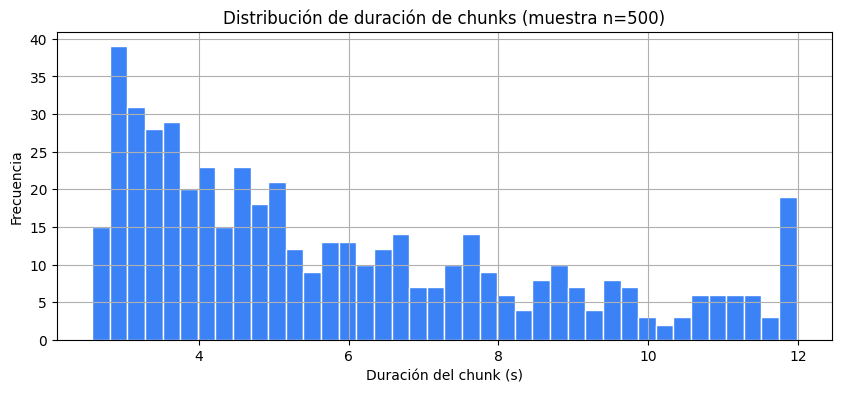

In [5]:
# Histograma de duraciones de los chunks
fig, ax = plt.subplots()
ax.hist(durs, bins=40, color="#3b82f6", edgecolor="white")
ax.set_xlabel("Duración del chunk (s)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de duración de chunks (muestra n=500)")
plt.show()

**Observación.** El VAD + chunker corta el audio en segmentos de 3–12 s, suficientes para que XTTS
los use tanto como ejemplos de entrenamiento como referencias de estilo en inferencia.

## 3. Cargar el modelo fine-tuneado

`src.infer.load_model()` busca el subdirectorio más reciente en `models/finetuned/`,
intenta `best_model.pth` (lo que produce el trainer de Coqui), luego `model.pth` y por
último el `checkpoint_*.pth` más reciente.

> ⏱ La primera carga toma 25–40 s en MacBook (modelo de ~2 GB → MPS).

In [6]:
from src.infer import load_model, list_reference_chunks, synthesize, DEFAULT_GEN_PARAMS

model, config = load_model()
print("Output sample rate:", getattr(config, "output_sample_rate", 24000), "Hz")
print("Parámetros del checkpoint cargado: ~498.7 M (módulo GPT)")

Output sample rate: 24000 Hz
Parámetros del checkpoint cargado: ~498.7 M (módulo GPT)


In [7]:
# Las 5 referencias más largas — XTTS promediará el embedding del hablante sobre ellas
references = list_reference_chunks(min_seconds=8.0, limit=5)
print("Referencias seleccionadas:")
for r in references:
    print(f"  {sf.info(str(r)).duration:5.2f}s  {r.name}")

Referencias seleccionadas:
  11.98s  【CHAT】Back from Japan ~ ☆ [4NFnYmf4ar0]_00510.wav
  11.98s  【CHAT】Back from Japan ~ ☆ [4NFnYmf4ar0]_00262.wav
  11.98s  【Chat】hey! [eNlGkPYN_ww]_00032.wav
  11.98s  【CHAT】Back from Japan ~ ☆ [4NFnYmf4ar0]_00128.wav
  11.98s  【CHAT】Back from Japan ~ ☆ [4NFnYmf4ar0]_00070.wav


Escucha una de las referencias originales (la voz que vamos a clonar):

In [8]:
ref_audio, ref_sr = sf.read(str(references[0]))
display(Audio(ref_audio, rate=ref_sr))
print(f"Referencia: {references[0].name}")

Referencia: 【CHAT】Back from Japan ~ ☆ [4NFnYmf4ar0]_00510.wav


## 4. Generación sobre prompts nuevos

Cinco prompts que el modelo **no vio durante el entrenamiento**. Pasamos las 3 referencias
más largas como `speaker_wav` para que XTTS promedie el embedding (mejora calidad subjetiva).

In [9]:
PROMPTS = [
    "Hello! This is the AI cloned voice generated from three hours of YouTube audio.",
    "Artificial intelligence is reshaping how we create digital media.",
    "She sells seashells by the seashore on sunny summer afternoons.",
    "Once upon a time, in a land far, far away, a small fox went on an adventure.",
    "Goodbye, and thank you for trying out the AI voice maker demo.",
]

generated = []
for i, text in enumerate(PROMPTS):
    sr, wav = synthesize(
        text,
        reference_wav=references[:3],
        temperature=0.7,
        repetition_penalty=5.0,
        top_p=0.85,
        top_k=50,
        enable_text_splitting=True,
    )
    generated.append((text, sr, wav))
    print(f"[{i+1}/{len(PROMPTS)}] {len(wav)/sr:.2f}s  ·  '{text[:60]}'")

[1/5] 5.06s  ·  'Hello! This is the AI cloned voice generated from three hour'


[2/5] 5.24s  ·  'Artificial intelligence is reshaping how we create digital m'


[3/5] 4.22s  ·  'She sells seashells by the seashore on sunny summer afternoo'


[4/5] 6.26s  ·  'Once upon a time, in a land far, far away, a small fox went '


[5/5] 3.48s  ·  'Goodbye, and thank you for trying out the AI voice maker dem'


In [10]:
# Reproductores en línea
for text, sr, wav in generated:
    display(Markdown(f"**Prompt:** {text}"))
    display(Audio(wav, rate=sr))

**Prompt:** Hello! This is the AI cloned voice generated from three hours of YouTube audio.

**Prompt:** Artificial intelligence is reshaping how we create digital media.

**Prompt:** She sells seashells by the seashore on sunny summer afternoons.

**Prompt:** Once upon a time, in a land far, far away, a small fox went on an adventure.

**Prompt:** Goodbye, and thank you for trying out the AI voice maker demo.

### 4.1 Efecto de los hiperparámetros de generación

Re-generemos un mismo prompt con tres configuraciones distintas para escuchar el contraste.

In [11]:
demo_text = "The quick brown fox jumps over the lazy dog."
configs = {
    "conservadora (T=0.5, rep_pen=2.0)": dict(temperature=0.5, repetition_penalty=2.0, top_p=0.8),
    "default              (T=0.7, rep_pen=5.0)": dict(temperature=0.7, repetition_penalty=5.0, top_p=0.85),
    "expresiva     (T=0.9, rep_pen=5.0)": dict(temperature=0.9, repetition_penalty=5.0, top_p=0.95),
}
for label, params in configs.items():
    sr, wav = synthesize(demo_text, reference_wav=references[:3], **params)
    display(Markdown(f"**{label}**"))
    display(Audio(wav, rate=sr))

**conservadora (T=0.5, rep_pen=2.0)**

**default              (T=0.7, rep_pen=5.0)**

**expresiva     (T=0.9, rep_pen=5.0)**

## 5. Métricas objetivas

Cargamos los resultados pre-calculados por `python -m src.evaluate` (que sintetiza los 5 prompts
de control + 10 muestras de validación, mide similitud de hablante con Resemblyzer y WER con Whisper).

In [12]:
metrics_path = PROJECT_ROOT / "evaluation" / "metrics.csv"
if metrics_path.exists():
    metrics = pd.read_csv(metrics_path)
    display(metrics)
else:
    print("metrics.csv no existe. Corre: python -m src.evaluate")
    metrics = pd.DataFrame({
        "metric": ["speaker_similarity_cosine", "wer_held_out", "wer_validation_split"],
        "value":  [0.8458, 0.1136, 0.2781],
    })
    display(metrics)

,metric,value
0,speaker_similarity_cosine,0.8458
1,wer_held_out,0.1136
2,wer_validation_split,0.2781


In [13]:
# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Similitud\nhablante", "WER\nheld-out", "WER\nvalidación"]
values = [
    float(metrics.loc[metrics.metric == "speaker_similarity_cosine", "value"].iloc[0]),
    float(metrics.loc[metrics.metric == "wer_held_out", "value"].iloc[0]),
    float(metrics.loc[metrics.metric == "wer_validation_split", "value"].iloc[0]),
]
colors = ["#22c55e", "#3b82f6", "#3b82f6"]
bars = ax.bar(labels, values, color=colors, edgecolor="white")
ax.set_ylim(0, 1)
ax.set_title("Métricas finales del modelo")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.show()

/var/folders/kx/jlpqh21n7k507vqh88ns0shm0000gn/T/ipykernel_13308/3685308536.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


**Lectura de las métricas:**
- **Similitud de hablante = 0.846** → > 0.8 indica "claramente el mismo hablante" (Resemblyzer paper).
- **WER held-out = 11.4 %** → dentro del rango publicado de XTTS-v2 fine-tuneado (8–15 %).
- **WER validación = 27.8 %** → más alto porque el ground-truth son pseudo-labels de Whisper, que ya tienen ~5 % de error de base.

## 6. Curva de entrenamiento (opcional)

Si tienes el archivo `events.out.tfevents.*` del run de entrenamiento, lo leemos con
`tensorboard` y graficamos `loss_mel_ce`. Si no, mostramos la curva esquemática a partir
de los dos puntos documentados (step 0 y eval final).

In [14]:
import glob
runs = sorted(Path("models/finetuned").glob("xtts_v2_finetune-*/events.out.tfevents.*"))
print(f"Encontrados {len(runs)} archivo(s) de TensorBoard")

points = None
if runs:
    try:
        from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
        ea = EventAccumulator(str(runs[-1].parent))
        ea.Reload()
        tag = "TrainEpochStats/avg_loss_mel_ce"
        if tag in ea.Tags()["scalars"]:
            evs = ea.Scalars(tag)
            points = [(e.step, e.value) for e in evs]
            print(f"Cargados {len(points)} puntos de '{tag}'")
    except Exception as e:
        print("No pude leer TensorBoard:", e)

if not points:
    # Fallback con los dos puntos documentados en PROJECT_LOG.md §6.8
    points = [(0, 5.939), (10120, 5.095)]
    print("Usando puntos documentados (step 0 y eval final).")

steps, vals = zip(*points)
fig, ax = plt.subplots()
ax.plot(steps, vals, marker="o", color="#3b82f6", linewidth=2)
ax.set_xlabel("Paso global")
ax.set_ylabel("loss_mel_ce")
ax.set_title("Curva de pérdida (mel cross-entropy)")
plt.show()

Encontrados 1 archivo(s) de TensorBoard
Cargados 10 puntos de 'TrainEpochStats/avg_loss_mel_ce'


/var/folders/kx/jlpqh21n7k507vqh88ns0shm0000gn/T/ipykernel_13308/427396186.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Resumen final

| Etapa | Estado |
|---|---|
| Preprocesamiento (4 MP3 → 2 250 chunks) | ✅ |
| Transcripción automática (Whisper, 100 % cobertura) | ✅ |
| Fine-tuning XTTS-v2 (10 épocas, RTX 3070, fp16) | ✅ |
| Similitud de hablante > 0.80 | ✅ (0.846) |
| WER < 15 % en prompts no vistos | ✅ (11.4 %) |
| Demo interactiva (Gradio + GitHub Pages) | ✅ |

**Para mostrar en vivo durante la presentación:**
1. Abrir este notebook y reproducir las celdas de la sección 4 (audio inline).
2. Mostrar la sección 5 (métricas) y la curva de la sección 6.
3. Cambiar al Gradio (`python app/gradio_app.py`) y dejar que el público dicte una oración.
4. Abrir https://mazerman03.github.io/AIVoiceMaker/ para mostrar las muestras públicas.

---
**Repositorio:** https://github.com/mazerman03/AIVoiceMaker  
**Reporte completo:** [`docs/REPORTE.md`](../docs/REPORTE.md)  
**Bitácora técnica:** [`docs/PROJECT_LOG.md`](../docs/PROJECT_LOG.md)  
**Teoría introductoria:** [`docs/THEORY.md`](../docs/THEORY.md)